In [1]:
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv("/content/sample_data/SMSSpamCollection",
                 sep='\t',
                 header=None,
                 names=['label', 'message']) #label=ham/spam, msg=actual msg

In [3]:
df.sample(5)

,label,message
2440,ham,Rightio. 11.48 it is then. Well arent we all u...
4618,ham,Good. do you think you could send me some pix?...
1494,ham,How are you with moneY...as in to you...money ...
3600,ham,Then wat r u doing now? Busy wif work?
3574,spam,You won't believe it but it's true. It's Incre...


In [4]:
df.shape

(5572, 2)

In [ ]:
# Data cleaning
#EDA
#Text preprocessing
#model building
# Evaluation
# inprovement depand on evaluation
# then website
#   Deployment

**1. DATA CLEANING**


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [7]:
encoder.fit_transform(df['label'])

array([0, 0, 1, ..., 0, 0, 0])

In [8]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
#missing value
df.isnull().sum()

,0
label,0
message,0


In [10]:
df.duplicated().sum()

np.int64(403)

In [11]:
df=df.drop_duplicates(keep='first')

In [12]:
df.duplicated().sum()

np.int64(0)

**2.EDA**

In [13]:
df['label'].value_counts()

,count
label,
ham,4516
spam,653


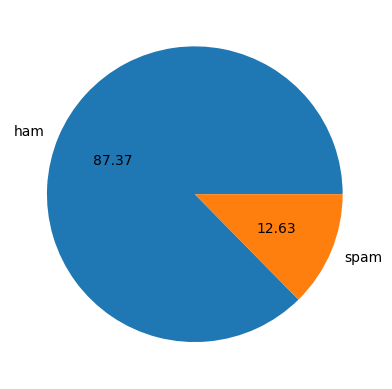

In [14]:
import matplotlib.pyplot as plt
plt.pie(df['label'].value_counts(), labels=['ham','spam'], autopct="%0.2f" )
plt.show()

In [ ]:
#Data imbalance


In [15]:
import nltk

In [16]:
df['num_characters']=df['message'].apply(len)

In [17]:
df.head()

,label,message,num_characters
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [18]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [19]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [20]:
#num of words
df['num_words']=df['message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [21]:
df.head()

,label,message,num_characters,num_words
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15


In [22]:
df["num_sentences"]=df['message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [23]:
df.head()

,label,message,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [24]:
#ham
df[df['label'] == 'ham'][
    ['num_characters','num_words','num_sentences']
].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.905890,17.267715,1.827724
std,56.715046,13.588065,1.394338
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [25]:
#spam
df[df['label'] == 'spam'][
    ['num_characters','num_words','num_sentences']
].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.704441,27.762634,2.986217
std,29.821348,6.993008,1.494815
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

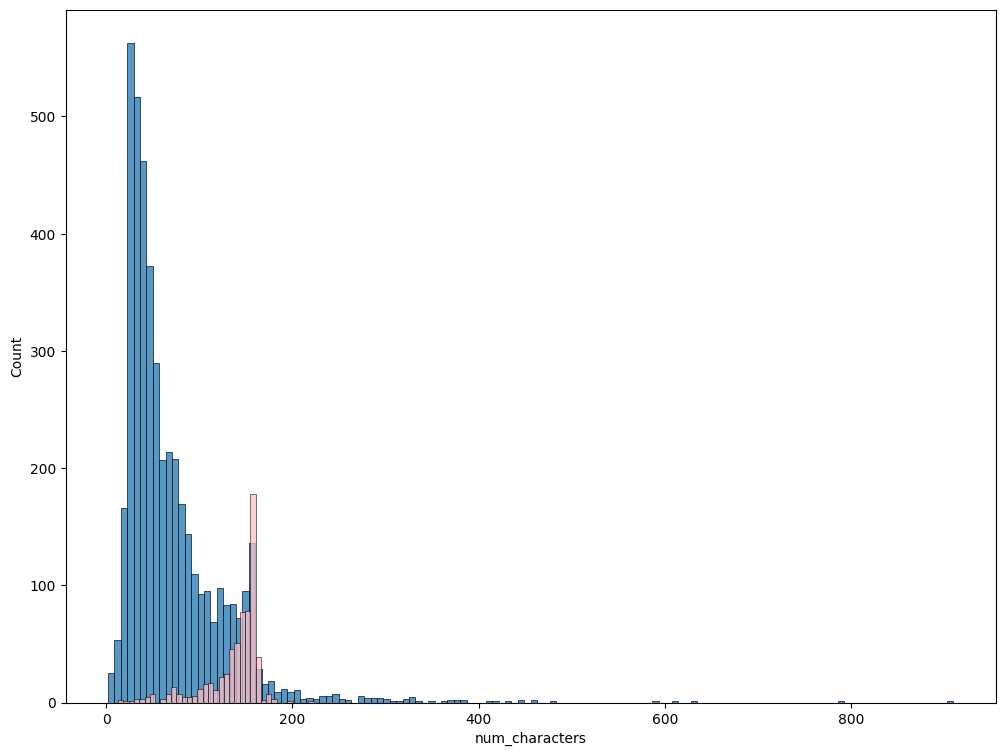

In [26]:
import seaborn as sns

plt.figure(figsize=(12,9))
sns.histplot(df[df['label'] == 'ham']['num_characters'])
sns.histplot(df[df['label'] == 'spam']['num_characters'], color='pink')

In [27]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

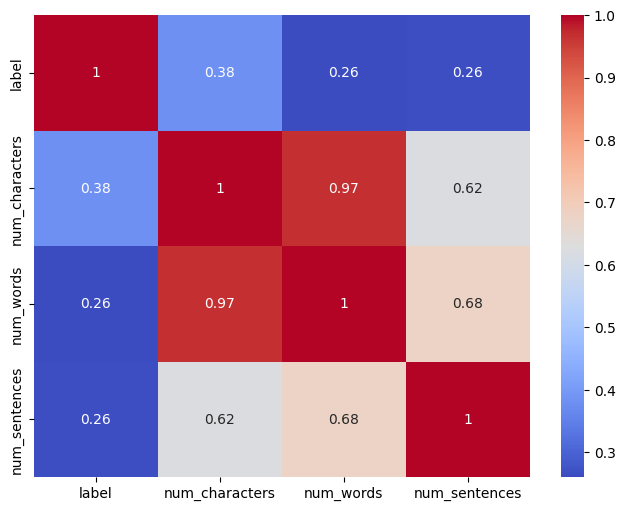

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['label','num_characters','num_words','num_sentences']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

Data preprocessing
> lower case,
> Tokenization,
> Removeing special character,
> Removeing stop words and punctuation,
> stemming.   #use nlp

In [29]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def transform_text(text):

    # 1️⃣ Lowercase
    text = text.lower()

    # 2️⃣ Tokenize
    words = nltk.word_tokenize(text)

    y = []

    for i in words:

        # 3️⃣ Keep only alphanumeric
        if i.isalnum():

            # 4️⃣ Remove stopwords & punctuation
            if i not in stopwords.words('english') and i not in string.punctuation:

                # 5️⃣ Stemming
                y.append(ps.stem(i))

    return " ".join(y)

In [32]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [33]:
df['transformed_message'] = df['message'].apply(transform_text)

In [34]:
df.head()

,label,message,num_characters,num_words,num_sentences,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [35]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color="white")

In [38]:
spam_wc = wc.generate(
    df[df['label'] == 1]['transformed_message'].str.cat(sep=" ")
)

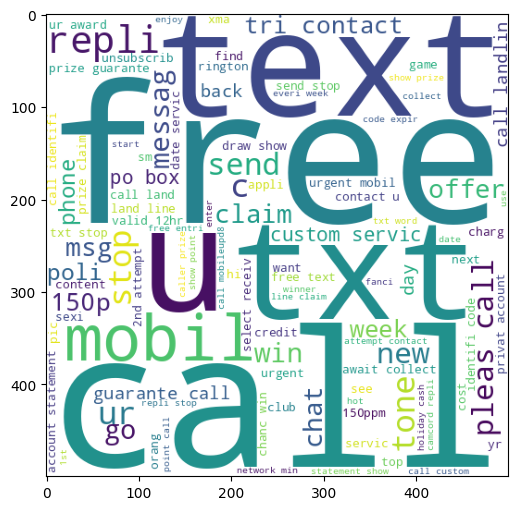

In [41]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [43]:
ham_wc = wc.generate(
    df[df['label'] == 0]['transformed_message'].str.cat(sep=" ")
)

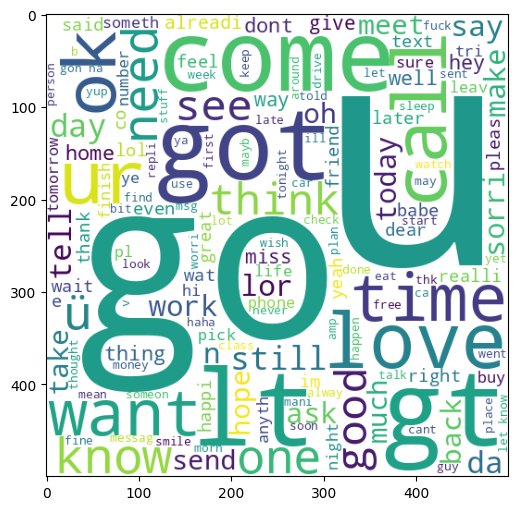

In [44]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [45]:
spam_corpus=[]
for msg in df[df['label']==1]['transformed_message'].tolist():
  for word in msg.split():
    spam_corpus.append(word)


In [46]:
len(spam_corpus)

9982

In [48]:
from collections import Counter
import pandas as pd

common_words = pd.DataFrame(Counter(spam_corpus).most_common(30)) #spam msg top 30 words are used

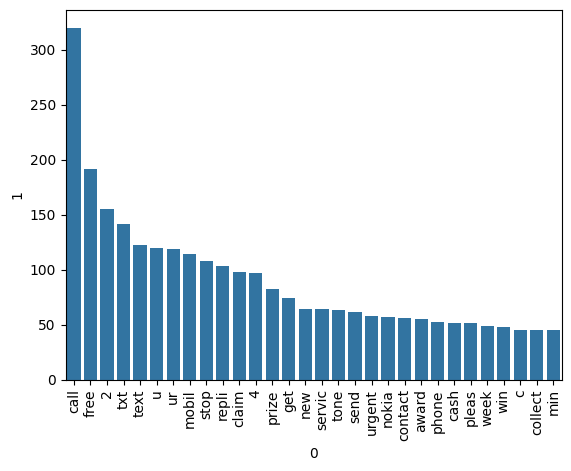

In [49]:
sns.barplot(
    x=common_words[0],
    y=common_words[1]
)

plt.xticks(rotation=90)
plt.show()

In [50]:
ham_corpus=[]
for msg in df[df['label']==0]['transformed_message'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [53]:
len(ham_corpus)

35939

In [51]:
common_words=pd.DataFrame(Counter(ham_corpus).most_common(30))

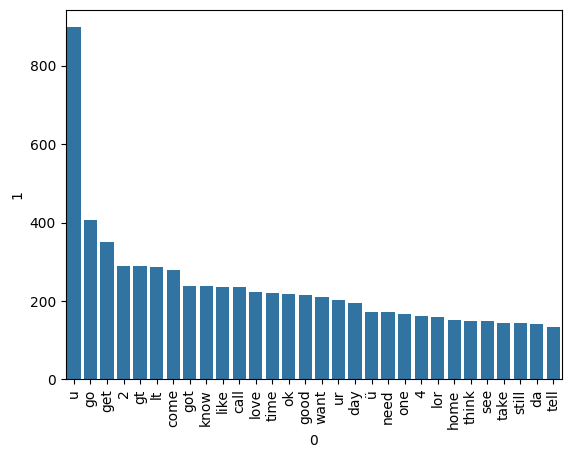

In [52]:
sns.barplot(
    x=common_words[0],
    y=common_words[1]

)
plt.xticks(rotation=90)
plt.show()

MODEL BUILDING

In [83]:
#textual data (naive bayes model used )

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)
x=tfidf.fit_transform(df['transformed_message']).toarray()
y=df['label']



In [84]:
x.shape

(5169, 3000)

In [85]:
y=df['label'].values

In [80]:
y

,label
0,0
1,0
2,1
3,0
4,0
...,...
5567,1
5568,0
5569,0
5570,0


In [86]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()
gnb.fit(x_train,y_train)
y_pred1=gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8636363636363636
[[790 118]
 [ 23 103]]
0.4660633484162896


In [87]:
mnb.fit(x_train,y_train)
y_pred2=mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))



0.9671179883945842
[[908   0]
 [ 34  92]]
1.0


In [88]:
bnb.fit(x_train,y_train)
y_pred3=bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9738878143133463
[[906   2]
 [ 25 101]]
0.9805825242718447


In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [90]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [91]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [92]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [94]:
train_classifier(svc,x_train,y_train,x_test,y_test)

(0.9729206963249516, 0.9803921568627451)

In [96]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, x_train,y_train,x_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9729206963249516
Precision -  0.9803921568627451
For  KN
Accuracy -  0.9187620889748549
Precision -  1.0
For  NB
Accuracy -  0.9671179883945842
Precision -  1.0
For  DT
Accuracy -  0.9400386847195358
Precision -  0.8555555555555555
For  LR
Accuracy -  0.9487427466150871
Precision -  0.9195402298850575
For  RF
Accuracy -  0.9680851063829787
Precision -  0.979381443298969
For  AdaBoost
Accuracy -  0.9226305609284333
Precision -  0.7948717948717948
For  BgC
Accuracy -  0.9632495164410058
Precision -  0.8793103448275862
For  ETC
Accuracy -  0.9777562862669246
Precision -  0.9724770642201835
For  GBDT
Accuracy -  0.9448742746615088
Precision -  0.9259259259259259
For  xgb
Accuracy -  0.9661508704061895
Precision -  0.9595959595959596


In [97]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [98]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.918762,1.000000
2,NB,0.967118,1.000000
0,SVC,0.972921,0.980392
5,RF,0.968085,0.979381
8,ETC,0.977756,0.972477
10,xgb,0.966151,0.959596
9,GBDT,0.944874,0.925926
4,LR,0.948743,0.919540
7,BgC,0.963250,0.879310
3,DT,0.940039,0.855556


In [99]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [100]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [102]:
voting.fit(x_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [104]:
y_pred = voting.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.97678916827853
Precision 0.9903846153846154


In [105]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [106]:
from sklearn.ensemble import StackingClassifier

In [108]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9835589941972921
Precision 0.9739130434782609


In [113]:
import pickle

pickle.dump(clf, open("model.pkl", "wb"))   # save stacking model
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))  # save vectorizer

STEP 1 — Prepare Your Project Folder
Your ML_Project folder should now have exactly:
# ML_Project
# │txt
# ├── app.py
# ├── model.pkl
# ├── vectorizer.pkl
# ├── requirements.
